In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scipy
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
from collections import Counter
from Bio import Align
from Bio import SeqIO
from Bio.Align import PairwiseAligner
import pysam
from difflib import SequenceMatcher
import scipy.sparse as sp
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick

sc.settings.verbosity = 2
# sc.logging.print_header()

# Load data

In [9]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 6.44 GB, difference +4.20 GB
CPU times: user 571 ms, sys: 2.16 s, total: 2.73 s
Wall time: 6.57 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/scanpy/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [10]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
# regev_genes = [g for g in regev_genes if g in adata.var_names]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

adata.X = adata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs[['phase']].head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:01)
computing score 'G2M_score'
    finished (0:00:01)
CPU times: user 1.95 s, sys: 1.59 s, total: 3.54 s
Wall time: 3.59 s


,phase
AAACCAAAGCAACTGC_hybrid,G2M
AAACCAAAGTAGGGCA_hybrid,S
AAACCAAAGTCTAGGC_hybrid,G1
AAACCATTCACGTAAT_hybrid,G2M
AAACCATTCAGGCAGA_hybrid,G2M


# Load cell cycle genes

In [11]:
### --------- load cell cycle genes ---------

# regev
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
print(f'Total regev genes: {len(regev_genes)}')
regev_genes = [g for g in regev_genes if g in adata.var_names]
print(f'\t in adata = {len(regev_genes)}')

# KEGG (hsa04110) -- downloaded from GSEA website
kdf = pd.read_json("../../resources/KEGG_CELL_CYCLE.v2026.1.Hs.json")
kegg_genes = kdf.loc['geneSymbols', 'KEGG_CELL_CYCLE']
print(f'Total KEGG cell cycle genes: {len(kegg_genes)}')
kegg_genes = [g for g in kegg_genes if g in adata.var_names]
print(f'\t in adata = {len(kegg_genes)}')

# GO 2025
cdf = pd.read_csv("../../resources/GO_2025_cc_genes.csv")
go_cc_genes = cdf['gene'].unique()
print(f'Total GO cell cycle genes: {len(go_cc_genes)}')
go_cc_genes = [g for g in go_cc_genes if g in adata.var_names]
print(f'\t in adata = {len(go_cc_genes)}')

Total regev genes: 97
	 in adata = 94
Total KEGG cell cycle genes: 125
	 in adata = 122
Total GO cell cycle genes: 857
	 in adata = 790


In [12]:
all_cc_genes = list(set(regev_genes) | set(kegg_genes) | set(go_cc_genes))
print(len(all_cc_genes))

884


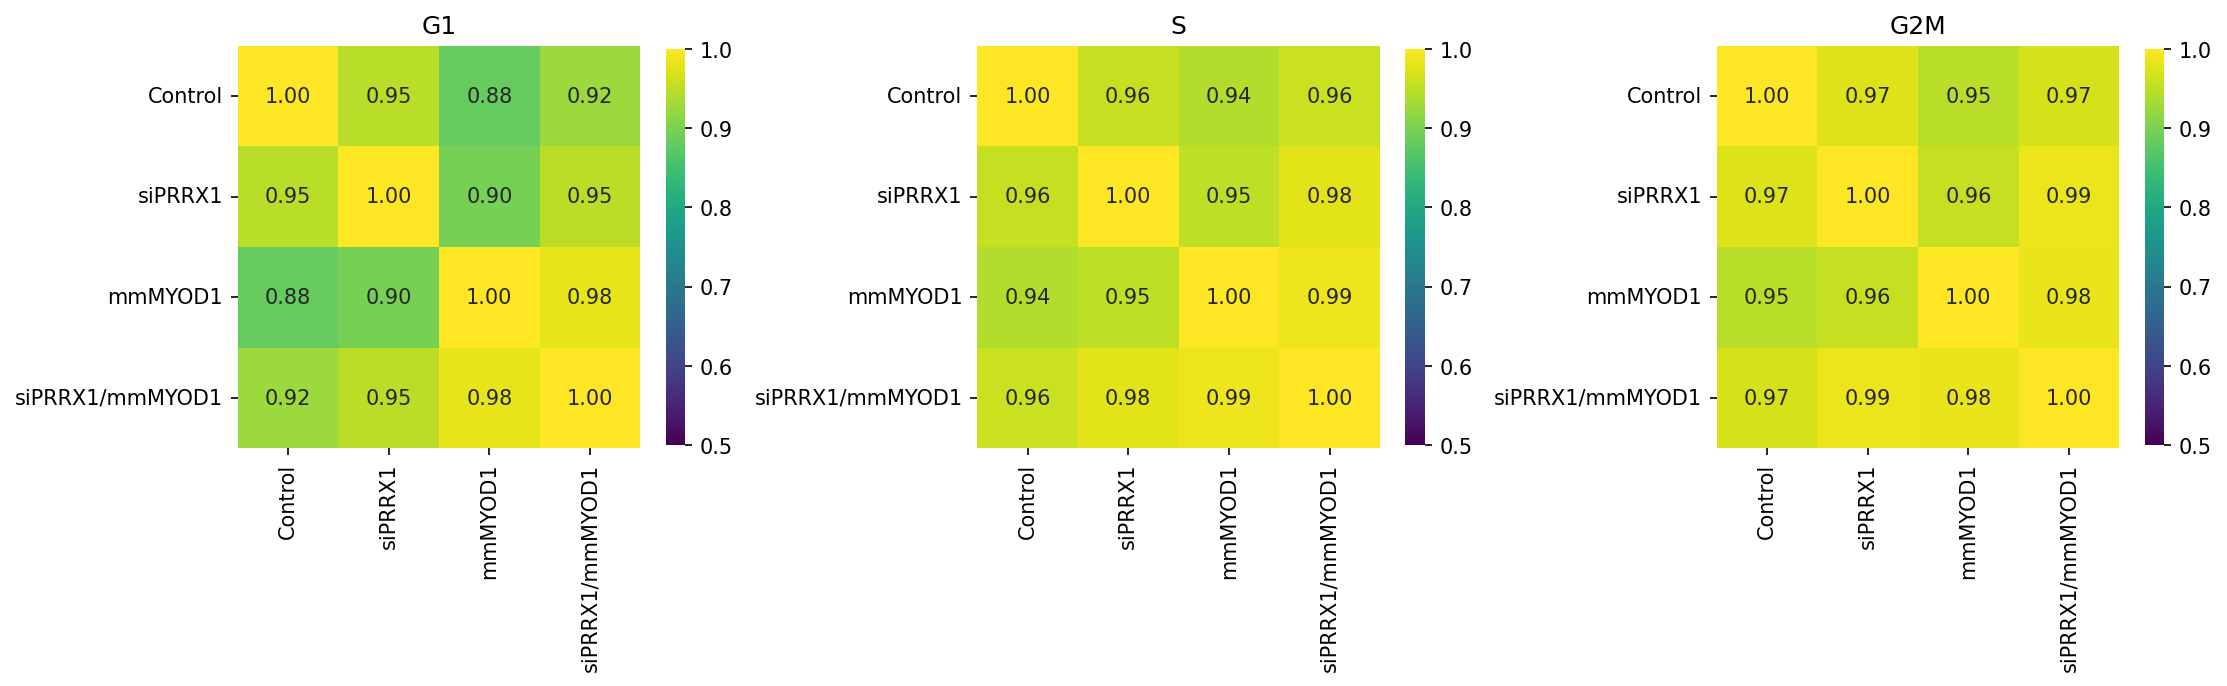

In [13]:
phases = ['G1', 'S', 'G2M']
conditions = ['Control', 'siPRRX1', 'mmMYOD1', 'siPRRX1/mmMYOD1']

corr_results = {}

for phase in phases:
    # subset cells in this phase
    ad_phase = adata[adata.obs['phase'] == phase].copy()

    # restrict to genes of interest
    ad_phase = ad_phase[:, all_cc_genes]

    # pseudobulk: mean expression per condition
    pb = (
        pd.DataFrame(ad_phase.X.toarray(), columns=all_cc_genes)
        .assign(condition=ad_phase.obs['pooled_condition'].values)
        .groupby('condition', observed=True)
        .mean()
    )

    # ensure consistent ordering
    pb = pb.loc[conditions]

    # compute correlation across conditions
    corr = pb.T.corr(method='pearson')  # genes × conditions → correlation of conditions

    corr_results[phase] = corr
    
    
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

for ax, phase in zip(axes, phases):
    sns.heatmap(
        corr_results[phase],
        vmin=0.5,
        vmax=1,
        cmap='viridis',
        annot=True,
        fmt=".2f",
        square=True,
        ax=ax,
        cbar_kws={'shrink': 0.7},
    )
    ax.set_title(phase)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
plt.tight_layout()
plt.show()

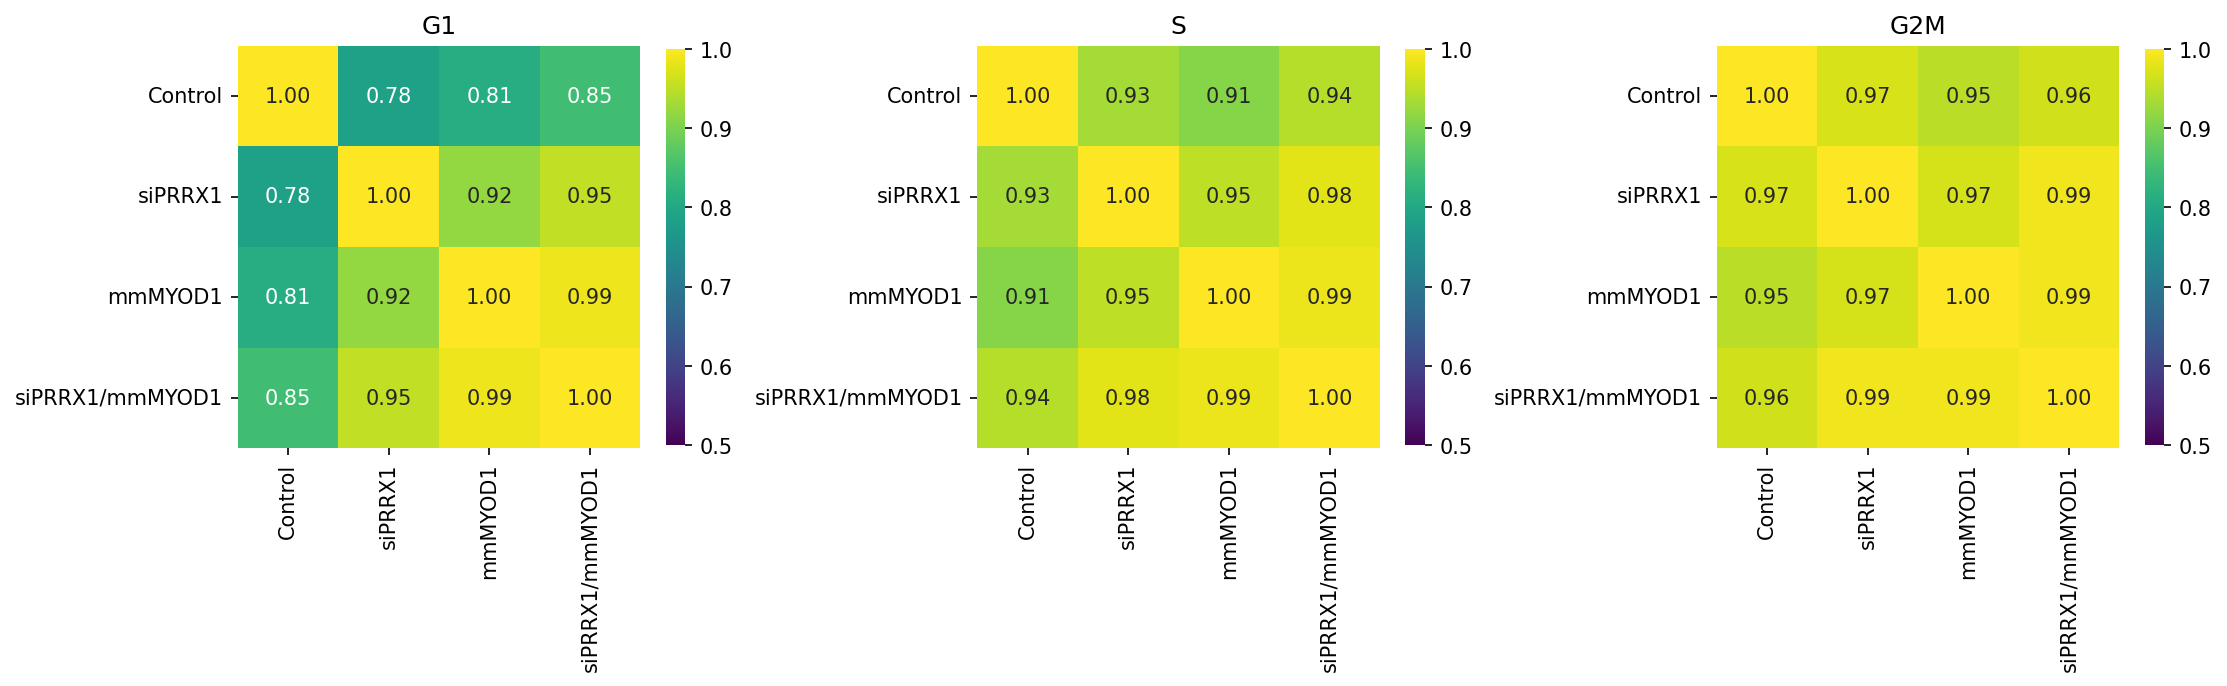

In [14]:
corr_results = {}

for phase in phases:
    # subset cells in this phase
    ad_phase = adata[adata.obs['phase'] == phase].copy()

    # restrict to genes of interest
    ad_phase = ad_phase[:, regev_genes]

    # pseudobulk: mean expression per condition
    pb = (
        pd.DataFrame(ad_phase.X.toarray(), columns=regev_genes)
        .assign(condition=ad_phase.obs['pooled_condition'].values)
        .groupby('condition', observed=True)
        .mean()
    )

    # ensure consistent ordering
    pb = pb.loc[conditions]

    # compute correlation across conditions
    corr = pb.T.corr(method='pearson')  # genes × conditions → correlation of conditions

    corr_results[phase] = corr
    
    
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

for ax, phase in zip(axes, phases):
    sns.heatmap(
        corr_results[phase],
        vmin=0.5,
        vmax=1,
        cmap='viridis',
        annot=True,
        fmt=".2f",
        square=True,
        ax=ax,
        cbar_kws={'shrink': 0.7},
    )
    ax.set_title(phase)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
plt.tight_layout()
plt.show()